In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Supermarket Analysis.csv")

print(df.head())
print(df.info())
print(df.describe())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

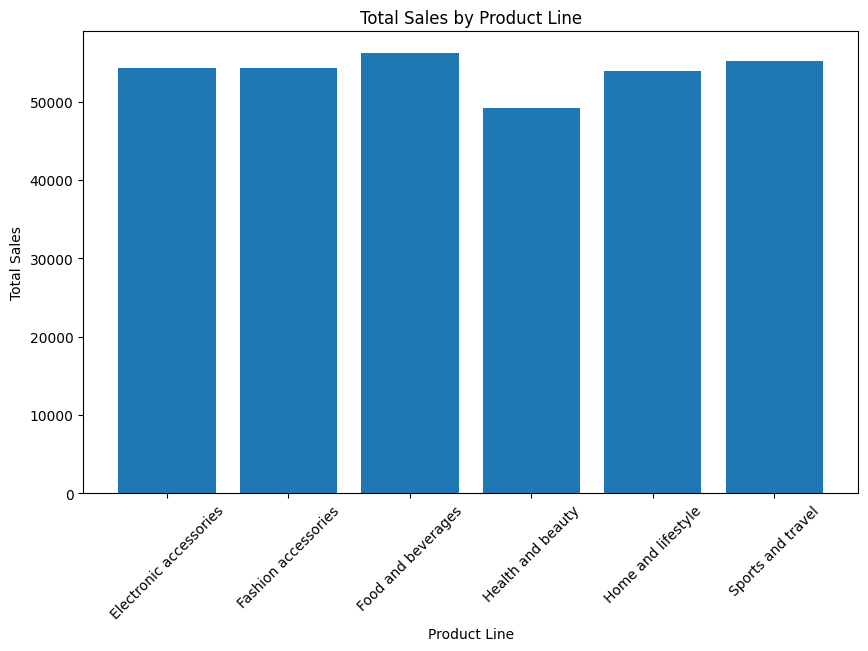

In [3]:
# Total Sales by Product Line
sales_by_product = df.groupby("Product line")["Sales"].sum()
plt.figure(figsize=(10, 6))
plt.bar(sales_by_product.index, sales_by_product.values)
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# This visualization compares the total sales generated by different product lines.
# It helps identify which product categories contribute the most to overall supermarket 
# revenue. Food and Beverages contribute the most.

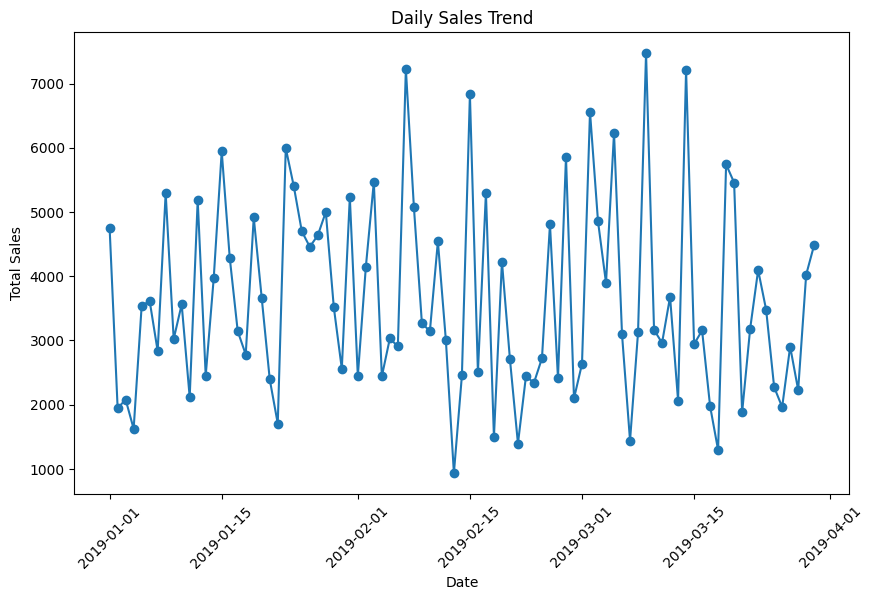

In [5]:
# Sales Trend Over Time
df["Date"] = pd.to_datetime(df["Date"])
daily_sales = df.groupby("Date")["Sales"].sum()
plt.figure(figsize=(10, 6))
plt.plot(daily_sales.index, daily_sales.values, marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# This visualization shows how total sales changed over time.
# It helps identify increases, decreases, and fluctuations in daily supermarket sales.

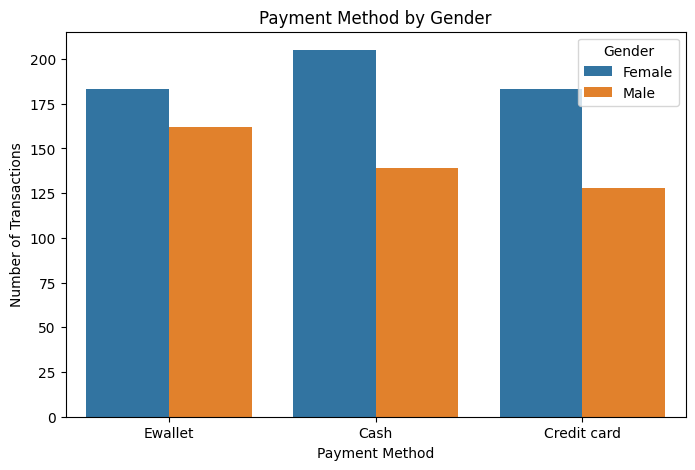

In [16]:
#Count Plot — Payment Method by Gender
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Payment",
    hue="Gender"
)
plt.title("Payment Method by Gender")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
# This chart displays the number of transactions made by male and female using each payment method. 
# It helps determine the most commonly used payment method by customers.
# Most customers pays through cash. Males purchase less than females.

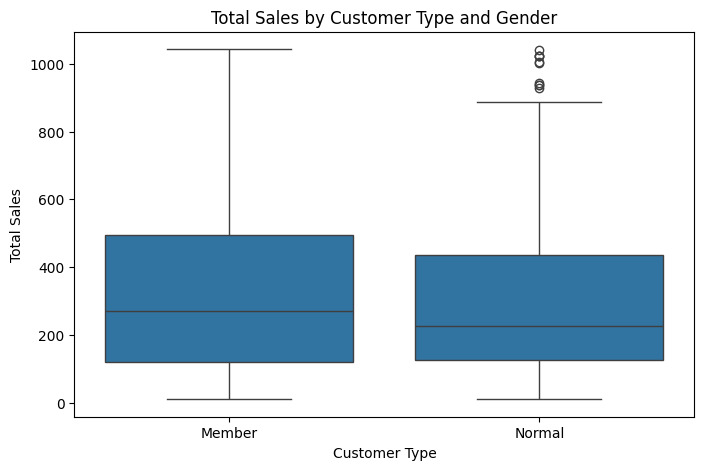

In [14]:
# Box Plot — Total Sales by Customer Type and Gender
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Customer type",
    y="Sales",
    # hue="Gender"
)
plt.title("Total Sales by Customer Type and Gender")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
# Member customers have a slightly higher median total sales than Normal customers.
# Both customer types show a wide range of sales values.
# Normal customers have several high-value outliers above 900.
# # Overall, Member customers show slightly higher typical sales.

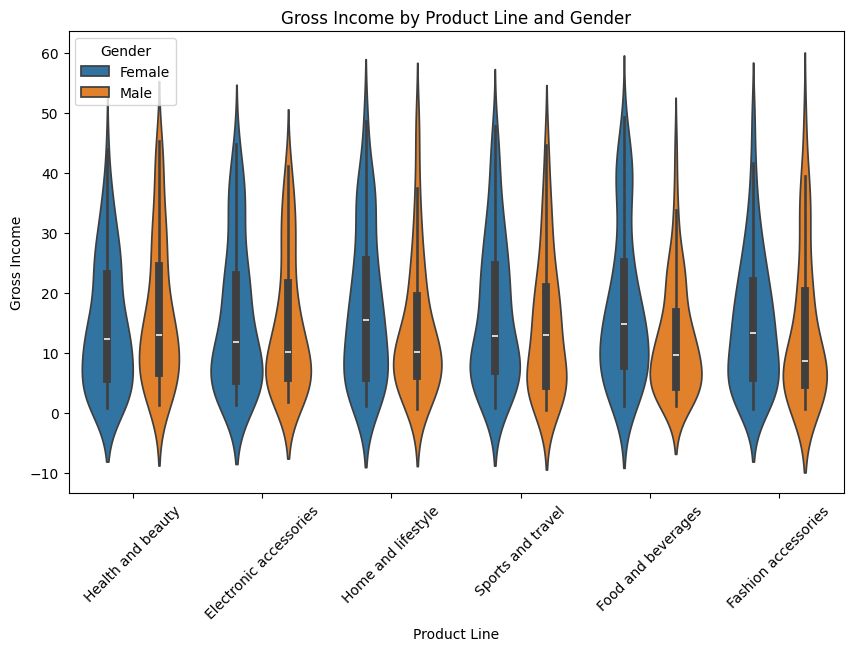

In [13]:
# Violin Plot — Gross Income by Product Line and Gender
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Product line",
    y="gross income",
    hue="Gender"
)
plt.title("Gross Income by Product Line and Gender")
plt.xlabel("Product Line")
plt.ylabel("Gross Income")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Gross income is mostly concentrated between 5 and 20 for both genders.
# Male and female customers show similar distributions across most product lines.
# Food and beverages and home and lifestyle show relatively wider distributions.
# Higher gross-income values occur less frequently.

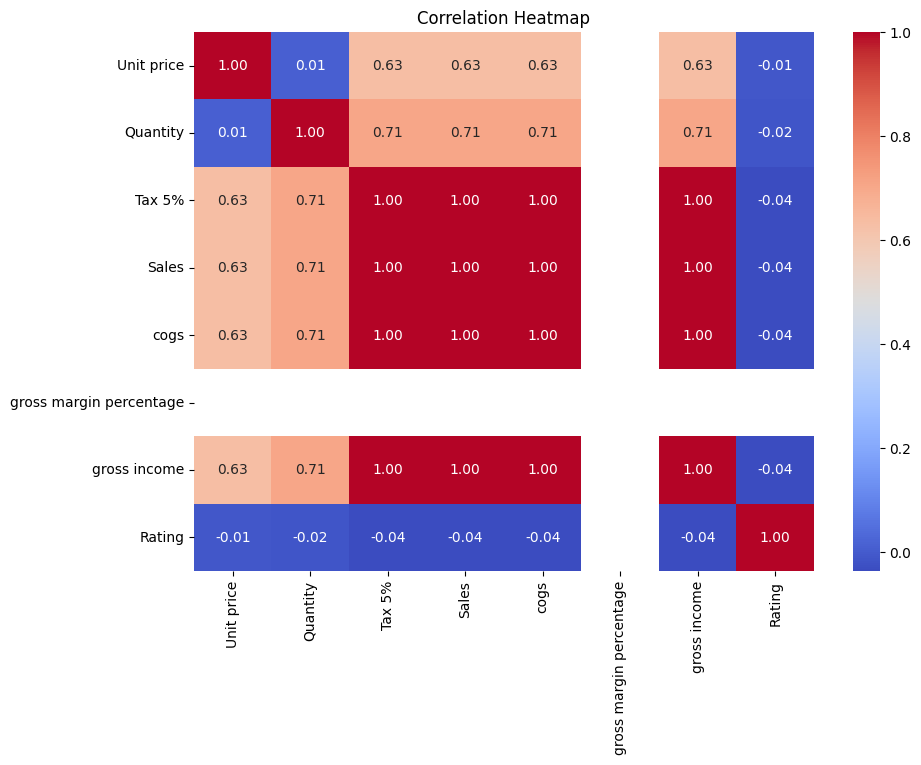

In [11]:
# Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# The correlation heatmap represents the relationship between numerical variables
# in the supermarket sales dataset. The correlation coefficient ranges from -1 to +1. 
# Unit price and quantity have almost no correlation (0.01), while quantity has a 
# relatively strong positive correlation with tax and sales (0.71). Tax, sales, cogs, 
# and gross income show very high correlations because these variables are mathematically 
# related in the dataset. Customer rating has very weak correlation with the other numerical 
# variables, with values close to zero. The heatmap makes it easy to identify strong and
# weak relationships between numerical variables.